### DFT

In [2]:
import cv2 
import numpy as np 
import matplotlib.pyplot as plt

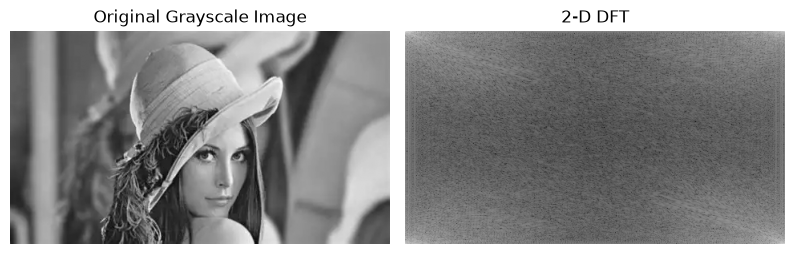

In [3]:
# Read the image in grayscale
img = cv2.imread(r"D:\image_processing_lab\lenna.png", cv2.IMREAD_GRAYSCALE)

# Check whether image was loaded
if img is None:
     print("Error: Image not found!") 
     exit()

# Convert image to float
img = np.float32(img)

F = np.fft.fft2(img)

plt.figure(figsize=(12, 8))

# Original image
plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')

# DFT
plt.subplot(2, 3, 2)
plt.imshow(np.log(1 + np.abs(F)), cmap='gray')
plt.title('2-D DFT')
plt.axis('off')

plt.tight_layout()
plt.show()

### INVERSE OF DFT TO ORIGINAL IMAGE

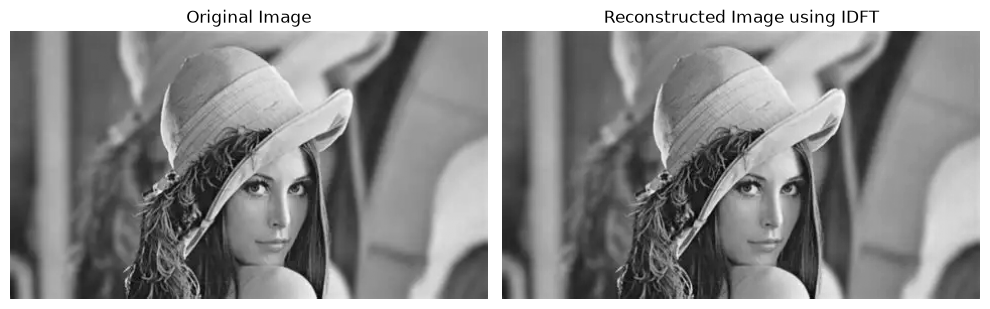

In [4]:
import cv2 
import numpy as np 
import matplotlib.pyplot as plt 
# Read grayscale image 
img = cv2.imread(r"D:\image_processing_lab\lenna.png", cv2.IMREAD_GRAYSCALE) 
# Convert to float 
img = np.float32(img) 

# 1. Calculate 2-D DFT 

F = np.fft.fft2(img) 

# 2. Inverse DFT 

reconstructed = np.fft.ifft2(F) 

reconstructed = np.real(reconstructed) 

# Convert to uint8 for display 
reconstructed = np.clip(reconstructed, 0, 255).astype(np.uint8) 

# 3. Display images  
plt.figure(figsize=(10, 4)) 
plt.subplot(1, 2, 1) 
plt.imshow(img, cmap='gray') 
plt.title('Original Image') 
plt.axis('off') 
plt.subplot(1, 2, 2) 
plt.imshow(reconstructed, cmap='gray') 
plt.title('Reconstructed Image using IDFT') 
plt.axis('off') 
plt.tight_layout() 
plt.show()

In [9]:
import cv2 
import numpy as np 
import matplotlib.pyplot as plt
from scipy.fftpack import dct

2-D DCT Coefficient Matrix:
[[ 4.4696508e+04 -4.9559395e+03 -1.1854793e+02 ...  3.1147766e+00
  -8.7409592e-01  1.2658691e+01]
 [ 3.5713477e+03  1.5151272e+03 -3.9319492e+03 ...  1.2964630e+00
  -1.6671143e+00 -1.7620850e-01]
 [ 2.9431360e+02  5.7816016e+02 -1.9137357e+03 ... -4.8322144e+00
   9.4237061e+00  1.2554291e+01]
 ...
 [ 8.1649771e+00  1.7387739e+00 -4.7251992e+00 ...  1.3111582e+00
   2.8326635e+00  9.6926057e-01]
 [-5.6752348e+00  1.8222654e-01  6.4135303e+00 ...  3.3858871e-01
  -3.0018864e+00 -3.4383726e+00]
 [ 1.8680899e+01 -2.6524596e+00  3.0775671e+00 ... -3.1066442e-01
   9.6773052e-01  2.8320475e+00]]


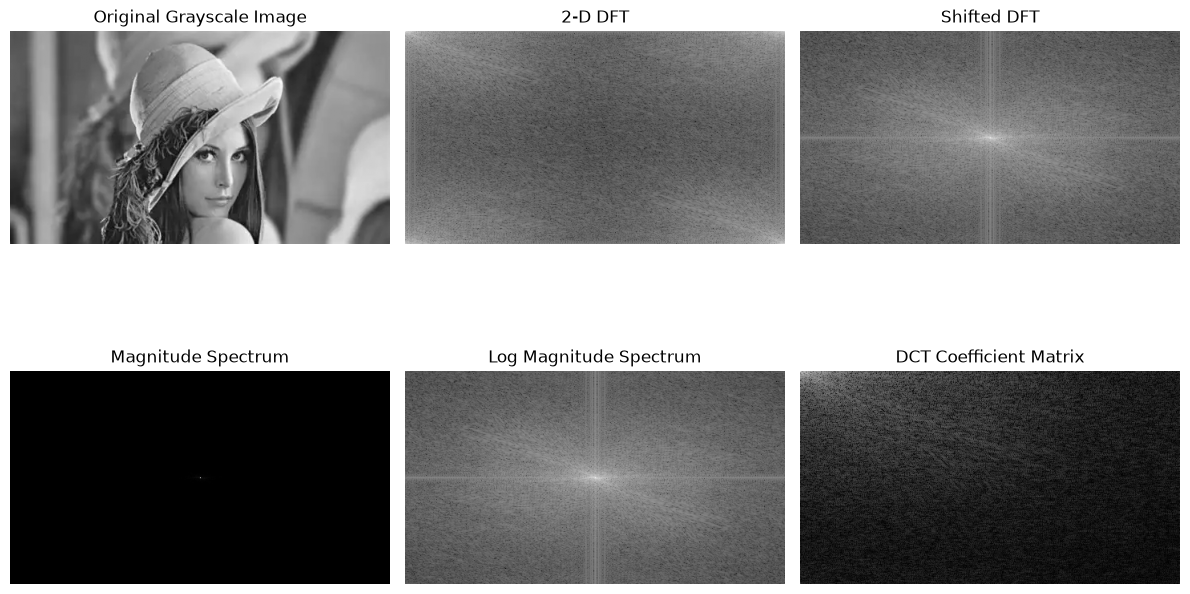

In [10]:
img = cv2.imread(r"D:\image_processing_lab\lenna.png", cv2.IMREAD_GRAYSCALE)

# Check whether image was loaded
if img is None:
     print("Error: Image not found!") 
     exit()

# Convert image to float
img = np.float32(img)

F = np.fft.fft2(img)

F_shifted = np.fft.fftshift(F)

magnitude_spectrum = np.abs(F_shifted)

log_spectrum = np.log(1 + magnitude_spectrum)

DCT = dct(dct(img.T, norm='ortho').T, norm='ortho')

print("2-D DCT Coefficient Matrix:") 
print(DCT)


plt.figure(figsize=(12, 8))



# Original image
plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')

# DFT
plt.subplot(2, 3, 2)
plt.imshow(np.log(1 + np.abs(F)), cmap='gray')
plt.title('2-D DFT')
plt.axis('off')

# Shifted DFT
plt.subplot(2, 3, 3) 
plt.imshow(np.log(1 + np.abs(F_shifted)), cmap='gray') 
plt.title('Shifted DFT') 
plt.axis('off') 

# Magnitude spectrum 
plt.subplot(2, 3, 4) 
plt.imshow(magnitude_spectrum, cmap='gray') 
plt.title('Magnitude Spectrum') 
plt.axis('off') 

# Logarithmic spectrum 
plt.subplot(2, 3, 5) 
plt.imshow(log_spectrum, cmap='gray') 
plt.title('Log Magnitude Spectrum') 
plt.axis('off') 

# DCT coefficients 
plt.subplot(2, 3, 6) 
plt.imshow(np.log(1 + np.abs(DCT)), cmap='gray') 
plt.title('DCT Coefficient Matrix') 
plt.axis('off')

plt.tight_layout()
plt.show()